# Ensemble Analysis

This notebook reads in and formats outputs from ensemble simulations so that you can evaluate and plot

### Import packages

In [28]:
#import packages
import flopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mp
import pandas as pd
import numpy as np
import os


#additional analysis tools
import flopy.utils.binaryfile as bf
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter


np.set_printoptions(threshold=np.inf)

#jupyter specific--included to show plots in notebook
%matplotlib inline 

# Setup static variables

In [29]:
nrow = 50 #number of rows
ncol = 50 #number of columns
nlay = 3  #number of layers
dx= 1000 #width of grid cells in x direction 
dy= 1000 #width of grid cells in y direction 
Lx = ncol*dx  #width of domain in x
Ly = nrow*dy #width of domain in y

ensembles = [[1,1,3,3,1,1,3],
             [1,1,3,3,1,1,1], 
             [1,1,3,3,1,3,3],
             [1,1,3,3,3,1,3],
             [2,2,2,2,2,2,2],
             [3,3,1,3,3,3,1],
             [3,3,3,1,3,3,1],
             [1,3,1,1,3,3,1],
             [3,1,1,1,3,3,1],
             [3,3,1,1,3,3,1]]

n_ens = len(ensembles)
print(n_ens, 'Ensembles to evaluate')


10 Ensembles to evaluate


## Read in outputs across all ensemble members and store as arrays 

In [30]:
#setup arrays to store the values
head_array = np.zeros((len(ensembles), nlay, ncol, nrow))
frf_array = np.zeros((len(ensembles),  nlay, ncol, nrow))
fff_array = np.zeros((len(ensembles),  nlay, ncol, nrow))
recharge_array = np.zeros((len(ensembles),  1, ncol, nrow))
et_array = np.zeros((len(ensembles),  1, ncol, nrow))
stor_array = np.zeros((len(ensembles),  1, ncol, nrow))
leakage_array = np.zeros((len(ensembles), 49)) #Note this is the only array that is 2D

# Loop through the ensembles and read the data
root_name = 'static_ensemble_' #root of the run names
for i in range(len(ensembles)):
    print('Assembling outputs for simulation ', i+1, ' of ', len(ensembles))
    name = root_name  #Create the file name from list 
    for k in range(len(ensembles[i])):
        string = str(ensembles[i][k])
        name = name + string   

    #read in the head and water budget files
    headobj = flopy.utils.binaryfile.HeadFile(name+'.hds')
    budgobj = flopy.utils.binaryfile.CellBudgetFile(name+'.cbc') 
    print('Head and water budget read in for ensemble member ', i+1)  
    
    head_array[i, :, :, :] = headobj.get_data(totim=1.0)
        
    tempfrf = np.squeeze(budgobj.get_data(text='flow right face', totim=1.0))
    frf_array[i, :, :, :] = tempfrf
        
    tempfff = np.squeeze(budgobj.get_data(text='FLOW FRONT FACE', totim=1.0))
    fff_array[i, :, :, :] = tempfff

    temprch = np.squeeze(budgobj.get_data(text='RECHARGE', totim=1.0))
    recharge_array[i,  :, :, :] = temprch[1]

    tempet = np.squeeze(budgobj.get_data(text='ET', totim=1.0))
    et_array[i, :, :, :] = tempet[1]

    templeak = budgobj.get_data(text='RIVER LEAKAGE', totim=1.0)
    leakage_array[i, :] = templeak[0].q




Assembling outputs for simulation  1  of  10
Head and water budget read in for ensemble member  1
Assembling outputs for simulation  2  of  10
Head and water budget read in for ensemble member  2
Assembling outputs for simulation  3  of  10
Head and water budget read in for ensemble member  3
Assembling outputs for simulation  4  of  10
Head and water budget read in for ensemble member  4
Assembling outputs for simulation  5  of  10
Head and water budget read in for ensemble member  5
Assembling outputs for simulation  6  of  10
Head and water budget read in for ensemble member  6
Assembling outputs for simulation  7  of  10
Head and water budget read in for ensemble member  7
Assembling outputs for simulation  8  of  10
Head and water budget read in for ensemble member  8
Assembling outputs for simulation  9  of  10
Head and water budget read in for ensemble member  9
Assembling outputs for simulation  10  of  10
Head and water budget read in for ensemble member  10


## Examples grabbing out values of interest from arrays
See below for some examples grabbing out values of interest. I'm not plotting them here you can either plot them in python or just copy values into excel for your plotting. 

### Notes: 
1. Remeber for all arrays except for river leakage the structure is: array_name[ensemble_number, vertical_layer, row, column]
2. River Leakage only has values for the river cells so its structure is: leakage_array[ensemble_number, column]
3. I have provided ET as an example here. There are arrays for fluxes recharge, head and storage that all have the same structure so you can just swap out the et_array name for one of the other names (e.g. 'head_array') to get values for that out. 

In [31]:
#print out the values for any of the stored arrays for all ensemble members. Every example below will print out one number for each ensemble member. 

#  ET at a single location in this case row 22, column 15
et_sigle_loc = et_array[:, 0, 22, 15]
print("ET at one location:")
print(et_sigle_loc) 

# ET summed across the domain
# Note here I am summing for all rows and all columns but you could change sum across any area by changing the row and column ranges provided
et_sum=np.zeros(len(ensembles))
for i in range(len(ensembles)):
    et_sum[i]= np.sum(et_array[i, 0, :,:])
print("Total ET:")
print(et_sum)

#  River leakage a single location, column 25
leak_sigle_loc = leakage_array[:, 25]
print("Leakage at one location:")
print(leak_sigle_loc) 

#  River leakage a single location, column 25
leak_total = np.sum(leakage_array, axis=1)
print("Total Leakage:")
print(leak_total) 

ET at one location:
[ -1.          -1.          -3.         -93.18694305 -16.71343422
 -13.32584286   0.           0.           0.           0.        ]
Total ET:
[  -578.67758111   -746.36804543  -1218.97739119 -36932.87702016
  -7247.87541497 -50929.98520914 -45059.44955952 -14060.41470043
 -46273.60808803 -45059.44955952]
Leakage at one location:
[ -386.64138794  -372.85958862  -374.61260986   342.30480957
 -1664.67089844  1469.71484375  2154.02319336   125.
  1904.6673584   2154.02319336]
Total Leakage:
[-17937.46916676 -14755.68751633 -17351.46009088  13983.94170141
  45094.46295547 111528.32836914 118058.40942383   6000.
 114312.35412598 118058.40942383]


In [32]:
import os
import numpy as np
import pandas as pd
import flopy

# 1) Set this to the folder that contains the .cbc/.hds files
# (Use the exact path you printed yesterday.)
workspace = "/workspaces/hwrs564b_course_materials_tracy/mywork/content_weekly/Homework3"

baseline_idx = 1
town_k, town_i, town_j = 0, 21, 38  # (layer,row,col) town well
n_ens = len(ensembles)

ET_total   = np.full(n_ens, np.nan)
RIV_total  = np.full(n_ens, np.nan)
CH_total   = np.full(n_ens, np.nan)
town_head  = np.full(n_ens, np.nan)

def build_modelname(ensemble_pick):
    name = "static_ensemble_"
    for p in range(7):
        name += str(ensemble_pick[p])
    return name

for ens_run in range(n_ens):
    modelname = build_modelname(ensembles[ens_run])

    cbc_file = os.path.join(workspace, modelname + ".cbc")
    hds_file = os.path.join(workspace, modelname + ".hds")

    if not os.path.exists(cbc_file):
        print("Missing CBC:", cbc_file)
        continue
    if not os.path.exists(hds_file):
        print("Missing HDS:", hds_file)
        continue

    bud = flopy.utils.CellBudgetFile(cbc_file)
    hds = flopy.utils.HeadFile(hds_file)

    t = bud.get_times()[-1]

    names = [n.decode().strip() if isinstance(n, (bytes, bytearray)) else str(n).strip()
             for n in bud.get_unique_record_names()]

    # ET (sometimes the label isn't exactly 'EVT' — but you said you're good using et_array,
    # so you can ignore ET_total here if you want.)
    if "EVT" in names:
        evt = bud.get_data(text="EVT", totim=t)[0]
        ET_total[ens_run] = evt["q"].sum()

    # River leakage (label might not be 'RIV' depending on package)
    if "RIV" in names:
        riv = bud.get_data(text="RIV", totim=t)[0]
        RIV_total[ens_run] = riv["q"].sum()

    # Constant head
    if "CONSTANT HEAD" in names:
        ch = bud.get_data(text="CONSTANT HEAD", totim=t)[0]
        CH_total[ens_run] = ch["q"].sum()

    head3d = hds.get_data(totim=hds.get_times()[-1])
    town_head[ens_run] = head3d[town_k, town_i, town_j]

df = pd.DataFrame({
    "ensemble": np.arange(n_ens),
    "modelname": [build_modelname(e) for e in ensembles],
    "CH_total_q": CH_total,
    "town_head": town_head,
})

df["d_CH_total_q"]  = df["CH_total_q"] - df.loc[baseline_idx, "CH_total_q"]
df["town_drawdown"] = df.loc[baseline_idx, "town_head"] - df["town_head"]

display(df)

,ensemble,modelname,CH_total_q,town_head,d_CH_total_q,town_drawdown
0,0,static_ensemble_1133113,-12958.830078,76.291603,3014.054688,2.131432
1,1,static_ensemble_1133111,-15972.884766,78.423035,0.000000,0.000000
2,2,static_ensemble_1133133,-12904.537109,76.240150,3068.347656,2.182884
3,3,static_ensemble_1133313,-8526.013672,73.132454,7446.871094,5.290581
4,4,static_ensemble_2222222,-56281.410156,75.105659,-40308.525391,3.317375
5,5,static_ensemble_3313331,-92073.250000,72.898552,-76100.365234,5.524483
6,6,static_ensemble_3331331,-78393.890625,72.531784,-62421.005859,5.891251
7,7,static_ensemble_1311331,2665.426270,66.217751,18638.311035,12.205284
8,8,static_ensemble_3111331,-73433.687500,72.898087,-57460.802734,5.524948
9,9,static_ensemble_3311331,-78393.890625,72.531784,-62421.005859,5.891251


In [33]:
import numpy as np
import pandas as pd

# -----------------------------
# Inputs you already have
# -----------------------------
# df must already contain: ensemble, modelname, CH_total_q, town_head (optional)
# and you have: et_sum (or ET_total array), leak_total (or RIV_total array)
# Example from earlier:
#   et_sum      = np.sum(et_array[:,0,:,:], axis=(1,2))
#   leak_total  = np.sum(leakage_array, axis=1)

baseline_idx = 1  # you said you're using 2222222 as baseline

# -----------------------------
# Build the summary dataframe
# -----------------------------
summary = pd.DataFrame({
    "Ensemble": df["ensemble"].values if "ensemble" in df.columns else np.arange(len(df)),
    "Modelname": df["modelname"].values,
    "CH_total_q": df["CH_total_q"].values,
    "ET_total": et_sum,
    "RIV_total": leak_total,
})

# Deltas vs baseline
summary["d_CH_total_q"] = summary["CH_total_q"] - summary.loc[baseline_idx, "CH_total_q"]
summary["d_ET_total"]   = summary["ET_total"]   - summary.loc[baseline_idx, "ET_total"]
summary["d_RIV_total"]  = summary["RIV_total"]  - summary.loc[baseline_idx, "RIV_total"]

# Keep only what you asked for (plus baseline for reference if you want)
summary_out = summary[["Ensemble", "Modelname", "d_CH_total_q", "d_ET_total", "d_RIV_total"]].copy()
display(summary_out)

,Ensemble,Modelname,d_CH_total_q,d_ET_total,d_RIV_total
0,0,static_ensemble_1133113,3014.054688,167.690464,-3181.781650
1,1,static_ensemble_1133111,0.000000,0.000000,0.000000
2,2,static_ensemble_1133133,3068.347656,-472.609346,-2595.772575
3,3,static_ensemble_1133313,7446.871094,-36186.508975,28739.629218
4,4,static_ensemble_2222222,-40308.525391,-6501.507370,59850.150472
5,5,static_ensemble_3313331,-76100.365234,-50183.617164,126284.015885
6,6,static_ensemble_3331331,-62421.005859,-44313.081514,132814.096940
7,7,static_ensemble_1311331,18638.311035,-13314.046655,20755.687516
8,8,static_ensemble_3111331,-57460.802734,-45527.240043,129068.041642
9,9,static_ensemble_3311331,-62421.005859,-44313.081514,132814.096940


In [34]:
print(df.loc[baseline_idx])

ensemble                               1
modelname        static_ensemble_1133111
CH_total_q                 -15972.884766
town_head                      78.423035
d_CH_total_q                         0.0
town_drawdown                        0.0
Name: 1, dtype: object


In [35]:
df["ET_total"] = np.sum(et_array[:, 0, :, :], axis=(1,2))
df["RIV_total"] = np.sum(leakage_array, axis=1)

df["d_ET_total"]  = df["ET_total"]  - df.loc[baseline_idx, "ET_total"]
df["d_RIV_total"] = df["RIV_total"] - df.loc[baseline_idx, "RIV_total"]

display(df)

,ensemble,modelname,CH_total_q,town_head,d_CH_total_q,town_drawdown,ET_total,RIV_total,d_ET_total,d_RIV_total
0,0,static_ensemble_1133113,-12958.830078,76.291603,3014.054688,2.131432,-578.677581,-17937.469167,167.690464,-3181.781650
1,1,static_ensemble_1133111,-15972.884766,78.423035,0.000000,0.000000,-746.368045,-14755.687516,0.000000,0.000000
2,2,static_ensemble_1133133,-12904.537109,76.240150,3068.347656,2.182884,-1218.977391,-17351.460091,-472.609346,-2595.772575
3,3,static_ensemble_1133313,-8526.013672,73.132454,7446.871094,5.290581,-36932.877020,13983.941701,-36186.508975,28739.629218
4,4,static_ensemble_2222222,-56281.410156,75.105659,-40308.525391,3.317375,-7247.875415,45094.462955,-6501.507370,59850.150472
5,5,static_ensemble_3313331,-92073.250000,72.898552,-76100.365234,5.524483,-50929.985209,111528.328369,-50183.617164,126284.015885
6,6,static_ensemble_3331331,-78393.890625,72.531784,-62421.005859,5.891251,-45059.449560,118058.409424,-44313.081514,132814.096940
7,7,static_ensemble_1311331,2665.426270,66.217751,18638.311035,12.205284,-14060.414700,6000.000000,-13314.046655,20755.687516
8,8,static_ensemble_3111331,-73433.687500,72.898087,-57460.802734,5.524948,-46273.608088,114312.354126,-45527.240043,129068.041642
9,9,static_ensemble_3311331,-78393.890625,72.531784,-62421.005859,5.891251,-45059.449560,118058.409424,-44313.081514,132814.096940


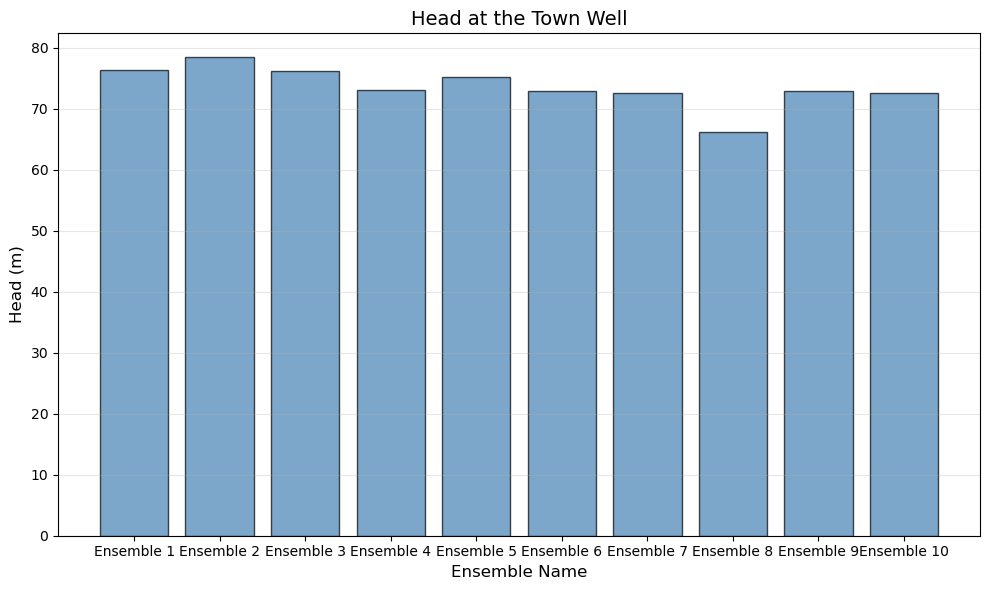

Head values at location (0, 21, 38):
Ensemble 1: 76.29 m
Ensemble 2: 78.42 m
Ensemble 3: 76.24 m
Ensemble 4: 73.13 m
Ensemble 5: 75.11 m
Ensemble 6: 72.90 m
Ensemble 7: 72.53 m
Ensemble 8: 66.22 m
Ensemble 9: 72.90 m
Ensemble 10: 72.53 m


In [39]:
# Extract head at the specified well location for each ensemble member
well_loc = (0, 21, 38)  # (layer, row, column)
head_at_well = head_array[:, well_loc[0], well_loc[1], well_loc[2]]

# Create ensemble names
ensemble_names = [f'Ensemble {i+1}' for i in range(len(ensembles))]

# Create the plot
plt.figure(figsize=(10, 6))
plt.bar(ensemble_names, head_at_well, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Ensemble Name', fontsize=12)
plt.ylabel('Head (m)', fontsize=12)
plt.title(f'Head at the Town Well', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Head values at location {well_loc}:")
for i, (name, head) in enumerate(zip(ensemble_names, head_at_well)):
    print(f"{name}: {head:.2f} m")


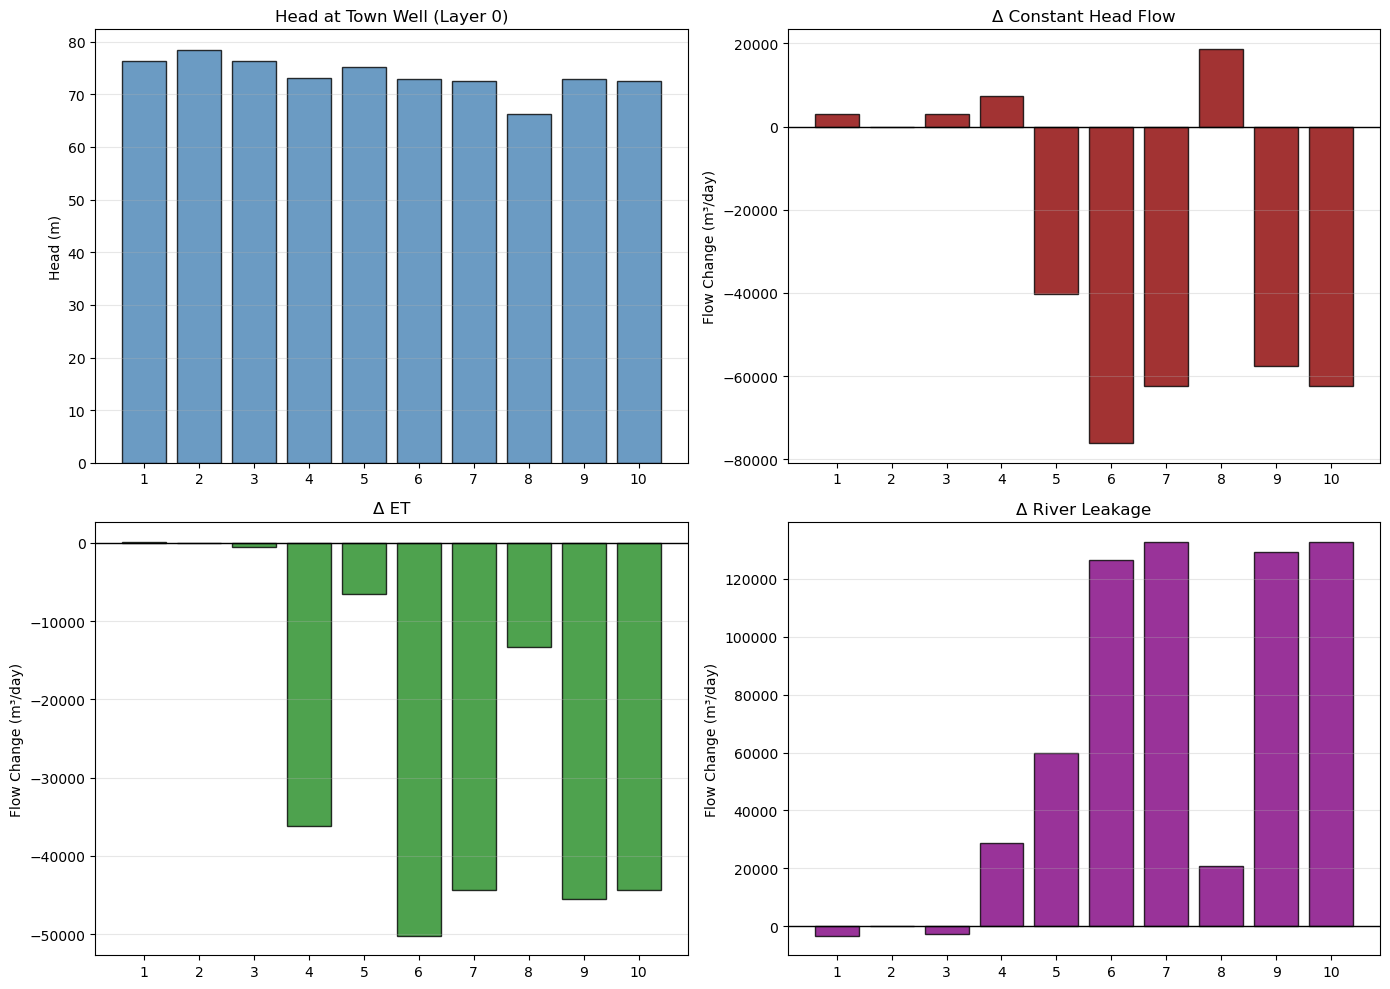

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# --- Extract head at town well (layer 0) ---
well_loc = (0, 21, 38)  # (layer, row, col)
head_at_well = head_array[:, well_loc[0], well_loc[1], well_loc[2]]

# --- Ensemble labels ---
ensemble_names = [f'{i + 1}' for i in range(len(head_at_well))]

# --- Extract delta values from dataframe ---
d_CH  = df["d_CH_total_q"].values
d_ET  = df["d_ET_total"].values
d_RIV = df["d_RIV_total"].values

# --- Create 2x2 subplot layout ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 1️⃣ Head plot
axes[0].bar(ensemble_names, head_at_well, 
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Head at Town Well (Layer 0)')
axes[0].set_ylabel('Head (m)')
axes[0].grid(axis='y', alpha=0.3)

# 2️⃣ Delta CH
axes[1].bar(ensemble_names, d_CH, 
            color='darkred', edgecolor='black', alpha=0.8)
axes[1].set_title('Δ Constant Head Flow')
axes[1].set_ylabel('Flow Change (m³/day)')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].grid(axis='y', alpha=0.3)

# 3️⃣ Delta ET
axes[2].bar(ensemble_names, d_ET, 
            color='forestgreen', edgecolor='black', alpha=0.8)
axes[2].set_title('Δ ET')
axes[2].set_ylabel('Flow Change (m³/day)')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].grid(axis='y', alpha=0.3)

# 4️⃣ Delta River
axes[3].bar(ensemble_names, d_RIV, 
            color='purple', edgecolor='black', alpha=0.8)
axes[3].set_title('Δ River Leakage')
axes[3].set_ylabel('Flow Change (m³/day)')
axes[3].axhline(0, color='black', linewidth=1)
axes[3].grid(axis='y', alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()